# 06 — From Forecast to Roster: Staffing Optimisation

Notebooks 01–05 took us from a synthetic Melbourne walk-in clinic to a daily
patient-volume **forecast** (XGBoost, MAE ≈ 17, with calibrated prediction
intervals). A forecast on its own doesn't run a clinic, though. The rostering
manager's question is blunter: **how many doctors, nurses and admin staff do I
roster tomorrow — and what does that cost?**

This notebook puts an **optimisation layer** on top of the forecast. It is a
two-stage pipeline:

| Stage | Question | Engine |
|---|---|---|
| **1 — Requirements** | How many of each role per hour to hit a wait-time target? | Intraday profile + **Erlang-C** + scenario sampling |
| **2 — Rostering** | Which shifts, at minimum cost, cover those requirements? | **OR-Tools CP-SAT** |

The headline design choice: we do **not** roster to the point forecast (that is
under-staffed roughly half the time). We roster to a **P90 demand day** built by
resampling the model's own empirical residuals, then size [Erlang-C](https://en.wikipedia.org/wiki/Erlang_(unit)#Erlang_C_formula)
so the wait-time service level holds on that day. Every assumption is explicit
and tunable in `staffing_config.yaml`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Locate the repo root and make the optimisation package importable.
REPO = Path.cwd()
while not (REPO / "ml-pipeline").exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO / "ml-pipeline" / "src"))

from optimization import StaffingOptimizer, load_assumptions
from optimization.demand_profile import hourly_arrivals, peak_hour
from optimization.queueing import prob_wait_exceeds, min_servers_for_sla, expected_wait_hours
from optimization.requirements import build_requirements, requirement_grid, requirement_distribution, planned_demand

plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3})

CONFIG = REPO / "ml-pipeline" / "src" / "optimization" / "staffing_config.yaml"
residuals = np.load(REPO / "ml-pipeline" / "models" / "cv_residuals.npy")
a = load_assumptions(CONFIG)
opt = StaffingOptimizer(residuals, assumptions=a)

print(f"Loaded {len(residuals)} CV residuals | mean {residuals.mean():+.1f}, std {residuals.std():.1f}")
print(f"SLA: ≤{a.wait_prob:.0%} of patients wait > {a.wait_target_min:.0f} min | "
      f"coverage P{int(a.coverage*100)} | utilisation cap {a.target_utilisation:.0%}")

Loaded 300 CV residuals | mean +7.2, std 25.2
SLA: ≤20% of patients wait > 30 min | coverage P90 | utilisation cap 85%


## 1. The demand distribution

The model's cross-validation residuals (`actual − predicted`) are our empirical
error distribution. Their mean is **positive** — the model under-forecasts
slightly — and the right tail is **fat** (those are surge days: thunderstorm
asthma, post-holiday spikes). We resample them to turn a single point forecast
into a distribution of plausible actual demand, then plan to its P90.

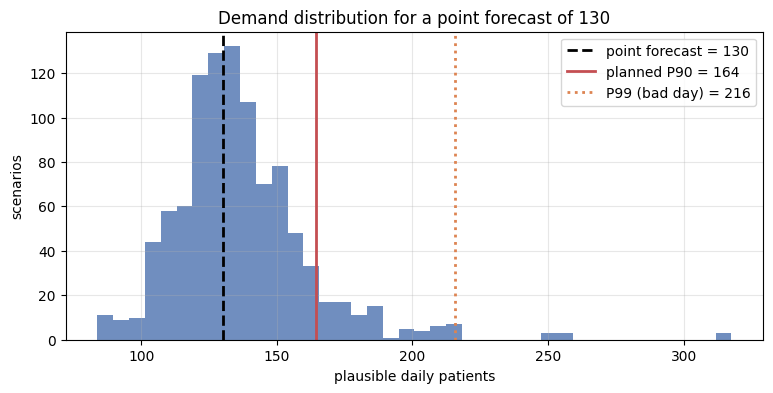

Planning to P90 = 164 adds a 34-patient buffer (26%) over the point forecast.


In [2]:
example_forecast = 130.0
scenarios = np.maximum(0, example_forecast + np.random.default_rng(a.random_seed).choice(
    residuals, size=a.n_scenarios, replace=True))
planned = planned_demand(example_forecast, residuals, a)
p99 = np.quantile(scenarios, 0.99)

fig, ax = plt.subplots()
ax.hist(scenarios, bins=40, color="#4C72B0", alpha=0.8)
ax.axvline(example_forecast, color="black", ls="--", lw=2, label=f"point forecast = {example_forecast:.0f}")
ax.axvline(planned, color="#C44E52", lw=2, label=f"planned P90 = {planned:.0f}")
ax.axvline(p99, color="#DD8452", ls=":", lw=2, label=f"P99 (bad day) = {p99:.0f}")
ax.set_xlabel("plausible daily patients"); ax.set_ylabel("scenarios"); ax.legend()
ax.set_title(f"Demand distribution for a point forecast of {example_forecast:.0f}")
plt.show()
print(f"Planning to P90 = {planned:.0f} adds a {planned - example_forecast:.0f}-patient "
      f"buffer ({(planned/example_forecast - 1):.0%}) over the point forecast.")

## 2. Intraday arrival profile

Erlang-C works on an **arrival rate**, so the daily total has to be spread
across opening hours. We only simulated *daily* data, so the shape here is an
**assumption** — a typical urgent-care curve with a mid-morning build, a midday
plateau and a post-work evening bump. Replace it the moment real hourly arrival
data exists (this is the single biggest modelling caveat).

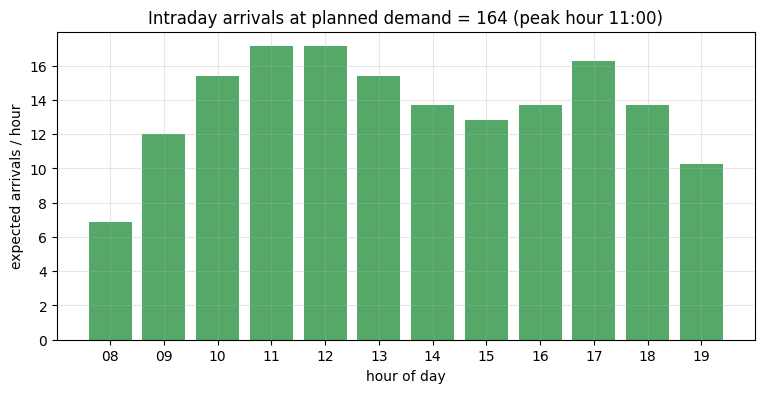

In [3]:
arr = hourly_arrivals(planned, a)
hours = list(arr.keys())
fig, ax = plt.subplots()
ax.bar([f"{h:02d}" for h in hours], list(arr.values()), color="#55A868")
ax.set_xlabel("hour of day"); ax.set_ylabel("expected arrivals / hour")
ax.set_title(f"Intraday arrivals at planned demand = {planned:.0f} (peak hour {peak_hour(planned, a):02d}:00)")
plt.show()

## 3. Erlang-C: how many doctors hit the wait-time target?

For a given arrival rate `λ` and per-doctor service rate `μ = 60/consult_time`,
Erlang-C gives the probability a patient waits longer than `t`. We add servers
until **P(wait > 30 min) ≤ 20%** *and* utilisation stays under the cap. The curve
below is for the busiest hour — note the sharp, non-linear drop: the difference
between an acceptable and an overwhelmed clinic is often a single clinician.

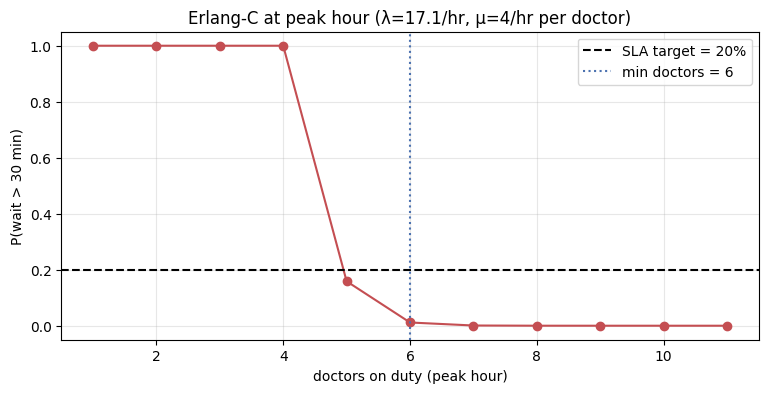

At the peak hour we need 6 doctors; expected wait then is 3.1 min.


In [4]:
doc = a.role("doctor")
lam_peak = arr[peak_hour(planned, a)]
t_hours = a.wait_target_min / 60.0
cc = list(range(1, 12))
pw = [prob_wait_exceeds(c, lam_peak, doc.service_rate, t_hours) for c in cc]
need = min_servers_for_sla(lam_peak, doc.service_rate, t_hours, a.wait_prob,
                           a.target_utilisation, floor=doc.min_on_duty)

fig, ax = plt.subplots()
ax.plot(cc, pw, "o-", color="#C44E52")
ax.axhline(a.wait_prob, color="black", ls="--", label=f"SLA target = {a.wait_prob:.0%}")
ax.axvline(need, color="#4C72B0", ls=":", label=f"min doctors = {need}")
ax.set_xlabel("doctors on duty (peak hour)"); ax.set_ylabel("P(wait > 30 min)")
ax.set_title(f"Erlang-C at peak hour (λ={lam_peak:.1f}/hr, μ={doc.service_rate:.0f}/hr per doctor)")
ax.legend(); plt.show()
print(f"At the peak hour we need {need} doctors; expected wait then is "
      f"{expected_wait_hours(need, lam_peak, doc.service_rate)*60:.1f} min.")

## 4. Uncertainty → the coverage quantile

Because demand is uncertain, the *required* number of doctors at the peak hour is
itself a distribution. We size to its P90 — the same coverage level we plan the
day to. This is the bridge between the forecast's uncertainty and a concrete
integer staffing number.

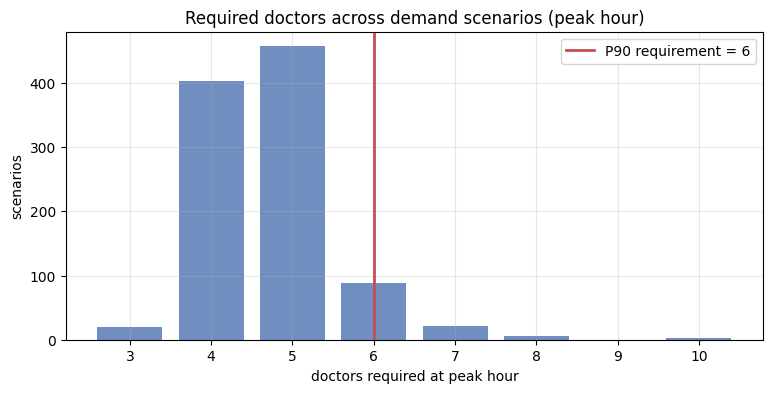

In [5]:
dist = requirement_distribution(example_forecast, residuals, a, role="doctor",
                                hour=peak_hour(planned, a))
fig, ax = plt.subplots()
vals, counts = np.unique(dist, return_counts=True)
ax.bar(vals, counts, color="#4C72B0", alpha=0.8)
ax.axvline(np.ceil(np.quantile(dist, a.coverage)), color="#C44E52", lw=2,
           label=f"P{int(a.coverage*100)} requirement = {int(np.ceil(np.quantile(dist, a.coverage)))}")
ax.set_xlabel("doctors required at peak hour"); ax.set_ylabel("scenarios")
ax.set_title("Required doctors across demand scenarios (peak hour)")
ax.legend(); plt.show()

## 5. Stage 2 — the minimum-cost roster (OR-Tools CP-SAT)

Stage 1 hands Stage 2 a per-hour, per-role **requirement grid**. CP-SAT then
chooses how many of each role to place on each rosterable shift (Early 08–14,
Mid 11–17, Late 14–20) to cover every hour at minimum cost, respecting the
safe-staffing floor. Coverage is a soft constraint with a large penalty, so the
solver always returns a usable roster and reports any shortfall.

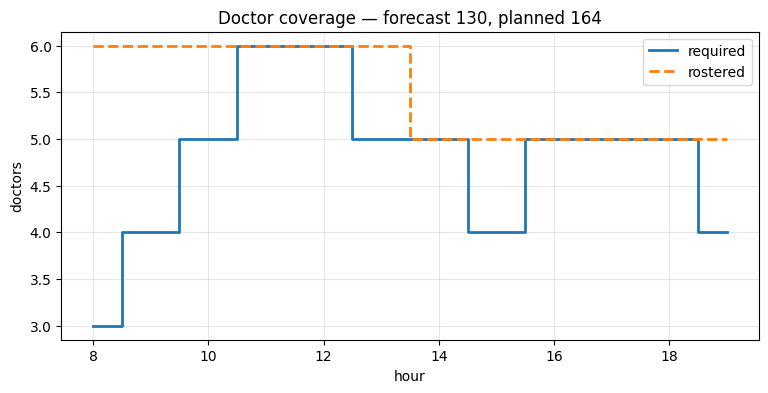

Roster (headcount by shift):
       doctor  nurse  admin
Early       6      4      2
Mid         0      0      0
Late        5      4      2

Bodies to roster: {'doctor': 11, 'nurse': 8, 'admin': 4}
Peak concurrent : {'doctor': 6, 'nurse': 4, 'admin': 2}
Daily cost: $13,980 | shortfall: 0 | worst-hour P(wait>30): 0.090


In [6]:
rec = opt.recommend(example_forecast)
grid = rec.requirement_grid

# Requirement vs achieved coverage, doctors.
fig, ax = plt.subplots()
hrs = a.open_hours
ax.step(hrs, [grid["doctor"][h] for h in hrs], where="mid", label="required", lw=2)
ax.step(hrs, [rec.coverage_grid["doctor"][h] for h in hrs], where="mid",
        ls="--", label="rostered", lw=2)
ax.set_xlabel("hour"); ax.set_ylabel("doctors"); ax.legend()
ax.set_title(f"Doctor coverage — forecast {example_forecast:.0f}, planned {rec.planned_demand:.0f}")
plt.show()

print("Roster (headcount by shift):")
print(pd.DataFrame(rec.headcount_by_shift).T)
print(f"\nBodies to roster: {rec.bodies_to_roster}")
print(f"Peak concurrent : {rec.peak_concurrent}")
print(f"Daily cost: ${rec.daily_cost:,.0f} | shortfall: {rec.shortfall} | "
      f"worst-hour P(wait>30): {max(rec.achieved_sla.values()):.3f}")

## 6. A worked week on the real held-out forecasts

Now the whole pipeline on the actual test-set XGBoost forecasts from notebook 05.
For each day we show the point forecast, the P90 we plan to, the roster, the
cost, and — as a back-test — whether the P90 plan would have covered the *actual*
demand. Over a long horizon that should happen on ≈ 90% of days, by construction.

In [7]:
tp = pd.read_csv(REPO / "ml-pipeline" / "models" / "test_predictions.csv", parse_dates=["date"])
tp = tp.sort_values("date").reset_index(drop=True)

rows = []
for _, r in tp.iterrows():
    rc = opt.recommend(float(r["pred_XGBoost"]))
    b = rc.bodies_to_roster
    rows.append({
        "date": r["date"].date(),
        "actual": int(r["patients"]),
        "forecast": round(r["pred_XGBoost"]),
        "planned_P90": round(rc.planned_demand),
        "doctors": b["doctor"], "nurses": b["nurse"], "admin": b["admin"],
        "daily_cost": round(rc.daily_cost),
        "covered_actual": rc.planned_demand >= r["patients"],
    })
week = pd.DataFrame(rows)
display(week.head(14))

cov = week["covered_actual"].mean()
print(f"\nP90 plan covered the actual on {week['covered_actual'].sum()}/{len(week)} "
      f"days ({cov:.0%}) — target was {a.coverage:.0%}.")
print(f"Total staffing cost over the {len(week)}-day test horizon: ${week['daily_cost'].sum():,.0f}")
print(f"Mean daily cost: ${week['daily_cost'].mean():,.0f}")

,date,actual,forecast,planned_P90,doctors,nurses,admin,daily_cost,covered_actual
0,2025-10-03,116,122,156,10,8,4,13080,True
1,2025-10-04,175,145,179,12,8,4,14880,True
2,2025-10-05,146,138,172,12,8,4,14880,True
3,2025-10-06,257,159,193,12,8,4,14880,False
4,2025-10-07,157,138,172,12,8,4,14880,True
5,2025-10-08,112,128,162,10,8,4,13080,True
6,2025-10-09,142,133,167,11,8,4,13980,True
7,2025-10-10,121,118,152,10,7,4,12690,True
8,2025-10-11,155,142,176,12,8,4,14880,True
9,2025-10-12,144,135,169,11,8,4,13980,True



P90 plan covered the actual on 85/90 days (94%) — target was 90%.
Total staffing cost over the 90-day test horizon: $1,225,260
Mean daily cost: $13,614


## 7. Sensitivity analysis

A roster is only as trustworthy as its assumptions. Two of the most consequential
knobs are the **doctor consult time** (how fast the clinic actually moves) and the
**wait-time SLA** (how much waiting is tolerable). Both move cost and headcount
substantially — exactly the levers a manager should negotiate before trusting the
number. The SLA sweep also exposes **which constraint actually binds**: at a
realistic 85% utilisation cap, utilisation — not the wait target — sets the
doctor count, so relaxing the SLA alone buys nothing.

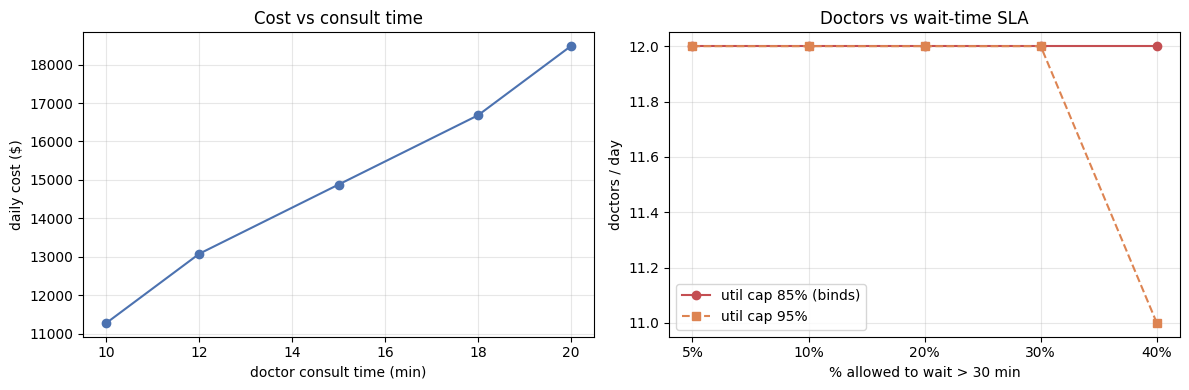

Consult time (min) -> doctors/day: {10: 8, 12: 10, 15: 12, 18: 14, 20: 16}
Wait SLA @85% util -> doctors/day: {'5%': 12, '10%': 12, '20%': 12, '30%': 12, '40%': 12}
Wait SLA @95% util -> doctors/day: {'5%': 12, '10%': 12, '20%': 12, '30%': 12, '40%': 11}

Insight: at 85% utilisation the cap binds, so loosening the wait SLA changes nothing. Relax the cap to 95% and the SLA starts to bite.


In [8]:
from optimization.assumptions import StaffingAssumptions
import dataclasses

base_fc = 150.0

# (a) Consult time
consult_grid = [10, 12, 15, 18, 20]
ct_cost, ct_doc = [], []
for ct in consult_grid:
    aa = dataclasses.replace(a, roles=tuple(
        dataclasses.replace(r, service_minutes=ct) if r.name == "doctor" else r for r in a.roles))
    rc = StaffingOptimizer(residuals, assumptions=aa).recommend(base_fc)
    ct_cost.append(rc.daily_cost); ct_doc.append(rc.bodies_to_roster["doctor"])

# (b) Wait SLA (fraction allowed to wait > 30 min), at two utilisation caps.
# This reveals *which constraint binds*: under the default 85% cap, utilisation
# dominates and the wait SLA does nothing until you also relax the cap.
sla_grid = [0.05, 0.10, 0.20, 0.30, 0.40]
sla_doc = {}
for util_cap in [0.85, 0.95]:
    docs = []
    for wp in sla_grid:
        aa = dataclasses.replace(a, wait_prob=wp, target_utilisation=util_cap)
        rc = StaffingOptimizer(residuals, assumptions=aa).recommend(base_fc)
        docs.append(rc.bodies_to_roster["doctor"])
    sla_doc[util_cap] = docs

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(consult_grid, ct_cost, "o-", color="#4C72B0")
ax1.set_xlabel("doctor consult time (min)"); ax1.set_ylabel("daily cost ($)")
ax1.set_title("Cost vs consult time")
xlabels = [f"{int(x*100)}%" for x in sla_grid]
ax2.plot(xlabels, sla_doc[0.85], "o-", color="#C44E52", label="util cap 85% (binds)")
ax2.plot(xlabels, sla_doc[0.95], "s--", color="#DD8452", label="util cap 95%")
ax2.set_xlabel("% allowed to wait > 30 min"); ax2.set_ylabel("doctors / day")
ax2.set_title("Doctors vs wait-time SLA"); ax2.legend()
plt.tight_layout(); plt.show()

print("Consult time (min) -> doctors/day:", dict(zip(consult_grid, ct_doc)))
print("Wait SLA @85% util -> doctors/day:", dict(zip(xlabels, sla_doc[0.85])))
print("Wait SLA @95% util -> doctors/day:", dict(zip(xlabels, sla_doc[0.95])))
print("\nInsight: at 85% utilisation the cap binds, so loosening the wait SLA "
      "changes nothing. Relax the cap to 95% and the SLA starts to bite.")

## 8. Assumptions register

Nothing above is allowed to hide a magic number. The full register travels with
every recommendation (and the API echoes it back), so a manager can audit and
challenge each input.

In [9]:
display(pd.DataFrame(rec.assumptions_register))

,assumption,value,unit,justification
0,Opening hours,08:00-20:00,clock,Clinic trading window; demand is distributed a...
1,Wait-time target,≤20% wait > 30 min,service level,The clinical/experience promise the roster mus...
2,Target utilisation cap,85%,fraction,Staff are never sized above this occupancy; ke...
3,Demand coverage,90% of days,fraction,Roster is sufficient on this fraction of sampl...
4,Scenarios sampled,1000,count,Empirical CV residuals resampled to build the ...
5,Arrival profile,assumed mid-morning/evening peaks,shape,PLACEHOLDER: derived from typical urgent-care ...
6,Standby trigger,known shock driver (e.g. thunderstorm asthma),flag,On-call locum standby; the global residual tai...
7,Doctor service time,15 min/patient,minutes,= 4.0 patients/hour per doctor.
8,Doctor cost,$150/hr,AUD,Fully-loaded hourly cost; min 1 on duty at all...
9,Nurse service time,10 min/patient,minutes,= 6.0 patients/hour per nurse.


## 9. Caveats — read before trusting the number

- **Arrival profile is assumed, not measured.** The intraday shape is the single
  biggest source of model risk. Replace it with real hourly arrivals.
- **Erlang-C assumes patients wait** (no walkouts/balking) and Poisson arrivals
  with exponential service. Real urgent care has **abandonment** — the natural
  extension is **Erlang-A**, which would slightly *reduce* required staff.
- **Residuals are homoscedastic.** We resample one global error pool, so every day
  carries the same ~10% breach risk and the data-driven tail can't tell a busy day
  from a dangerous one. That is why **standby keys off a known shock driver**
  (thunderstorm-asthma conditions), not the residual tail.
- **Costs and service times are placeholders.** Plausible Melbourne figures, but
  tune them in `staffing_config.yaml` against real award rates.
- **Skill substitution is fixed.** Each role is sized on its own queue; we don't
  model a nurse practitioner absorbing doctor workload.

## Summary

We turned a daily point forecast into an auditable, minimum-cost roster that
keeps a wait-time promise on ~90% of days. Stage 1 (Erlang-C + scenario sampling)
answers *how many*; Stage 2 (OR-Tools CP-SAT) answers *which shifts, at what cost*.
The forecast tells you the weather; this layer tells you what to wear.